# **Video Classification Using A Hybrid Model and PyTorch**

### Import the required libraries

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import Inception_V3_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


### Download Data

>NOTE: Answer 'y' if you need too, otherwise answer 'n'

In [6]:
# Data Download and Setup
import os
import urllib.request
import zipfile
import rarfile
from tqdm import tqdm
import requests
import ssl

def download_with_progress(url, filename, verify_ssl=True):
    """Download file with progress bar"""
    try:
        # First try with SSL verification
        response = requests.get(url, stream=True, verify=verify_ssl)
        total_size = int(response.headers.get('content-length', 0))
        
        with open(filename, 'wb') as file, tqdm(
            desc=filename,
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024,
        ) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                size = file.write(chunk)
                pbar.update(size)
        return True
    except requests.exceptions.SSLError:
        # If SSL fails, try without verification
        print("SSL verification failed, trying without SSL verification...")
        try:
            response = requests.get(url, stream=True, verify=False)
            total_size = int(response.headers.get('content-length', 0))
            
            with open(filename, 'wb') as file, tqdm(
                desc=filename,
                total=total_size,
                unit='B',
                unit_scale=True,
                unit_divisor=1024,
            ) as pbar:
                for chunk in response.iter_content(chunk_size=8192):
                    size = file.write(chunk)
                    pbar.update(size)
            return True
        except Exception as e:
            print(f"Download failed: {e}")
            return False
    except Exception as e:
        print(f"Download failed: {e}")
        return False

def download_with_urllib(url, filename):
    """Alternative download method using urllib"""
    try:
        # Create SSL context that doesn't verify certificates
        ssl_context = ssl.create_default_context()
        ssl_context.check_hostname = False
        ssl_context.verify_mode = ssl.CERT_NONE
        
        def show_progress(block_num, block_size, total_size):
            downloaded = block_num * block_size
            if total_size > 0:
                percent = min(100, (downloaded * 100) // total_size)
                print(f"\rDownloading {filename}: {percent}% ({downloaded // (1024*1024)} MB)", end='')
        
        urllib.request.urlretrieve(url, filename, reporthook=show_progress)
        print()  # New line after progress
        return True
    except Exception as e:
        print(f"urllib download failed: {e}")
        return False

def setup_ucf101_dataset():
    """Download and setup UCF101 dataset and train/test splits"""
    
    # Create data directory if it doesn't exist
    os.makedirs('data', exist_ok=True)
    
    # UCF101 dataset URLs
    ucf101_url = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
    train_test_splits_url = "https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip"
    
    # Alternative URLs (in case the main site is down)
    alt_ucf101_urls = [
        "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar",
        "http://crcv.ucf.edu/data/UCF101/UCF101.rar"  # HTTP fallback
    ]
    
    alt_splits_urls = [
        "https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip",
        "http://crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip"  # HTTP fallback
    ]
    
    # Check if dataset already exists
    if os.path.exists('data/UCF-101') and len(os.listdir('data/UCF-101')) > 0:
        print("UCF101 dataset already exists, skipping download")
    else:
        print("Downloading UCF101 dataset (this may take a while, ~7GB)...")
        user_confirm = input("This will download a 7GB file. Continue? (y/n): ")
        if user_confirm.lower() == 'y':
            downloaded = False
            
            # Try multiple download methods and URLs
            for i, url in enumerate(alt_ucf101_urls):
                print(f"Trying download method {i+1} from: {url}")
                
                # Try requests first
                if download_with_progress(url, 'data/UCF101.rar', verify_ssl=False):
                    downloaded = True
                    break
                    
                # Try urllib as fallback
                print("Trying alternative download method...")
                if download_with_urllib(url, 'data/UCF101.rar'):
                    downloaded = True
                    break
            
            if downloaded:
                print("UCF101 dataset downloaded successfully")
                
                # Extract RAR file
                print("Extracting UCF101 dataset...")
                try:
                    with rarfile.RarFile('data/UCF101.rar') as rf:
                        rf.extractall('data/')
                    print("UCF101 dataset extracted successfully")
                    
                    # Clean up RAR file to save space
                    os.remove('data/UCF101.rar')
                    print("Cleaned up RAR file")
                except Exception as e:
                    print(f"Extraction failed: {e}")
                    print("You may need to extract UCF101.rar manually")
            else:
                print("All download methods failed!")
                print("Manual download options:")
                print("1. Download from: https://www.crcv.ucf.edu/data/UCF101/UCF101.rar")
                print("2. Or try: wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar")
                print("3. Place the file in the data/ directory and extract manually")
        else:
            print("Download cancelled. Please download UCF101.rar manually to the data/ directory")
    
    # Check if train/test splits already exist
    if os.path.exists('data/ucfTrainTestlist'):
        print("Train/test splits already exist, skipping download")
    else:
        print("Downloading train/test splits...")
        downloaded = False
        
        # Try multiple download methods and URLs
        for i, url in enumerate(alt_splits_urls):
            print(f"Trying download method {i+1} from: {url}")
            
            # Try requests first
            if download_with_progress(url, 'data/UCF101TrainTestSplits.zip', verify_ssl=False):
                downloaded = True
                break
                
            # Try urllib as fallback
            print("Trying alternative download method...")
            if download_with_urllib(url, 'data/UCF101TrainTestSplits.zip'):
                downloaded = True
                break
        
        if downloaded:
            print("Train/test splits downloaded successfully")
            
            # Extract ZIP file
            print("Extracting train/test splits...")
            try:
                with zipfile.ZipFile('data/UCF101TrainTestSplits.zip', 'r') as zip_ref:
                    zip_ref.extractall('data/')
                print("✓ Train/test splits extracted successfully")
                
                # Clean up ZIP file
                os.remove('data/UCF101TrainTestSplits.zip')
                print("Cleaned up ZIP file")
            except Exception as e:
                print(f"Extraction failed: {e}")
                print("You may need to extract UCF101TrainTestSplits.zip manually")
        else:
            print("All download methods failed!")
            print("Manual download options:")
            print("1. Download from: https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip")
            print("2. Or try: wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip")
            print("3. Place the file in the data/ directory and extract manually")
    
    # Verify the setup
    print("\n" + "="*50)
    print("DATASET SETUP VERIFICATION")
    print("="*50)
    
    if os.path.exists('data/UCF-101'):
        num_classes = len([d for d in os.listdir('data/UCF-101') if os.path.isdir(os.path.join('data/UCF-101', d))])
        print(f"UCF-101 directory found with {num_classes} classes")
    else:
        print("UCF-101 directory not found")
        print("  Manual setup instructions:")
        print("  1. Download UCF101.rar to data/ directory")
        print("  2. Extract: unrar x data/UCF101.rar data/")
        print("  3. Or use: 7z x data/UCF101.rar -odata/")
    
    if os.path.exists('data/ucfTrainTestlist'):
        train_files = [f for f in os.listdir('data/ucfTrainTestlist') if f.startswith('trainlist')]
        test_files = [f for f in os.listdir('data/ucfTrainTestlist') if f.startswith('testlist')]
        print(f"✓ Train/test splits found: {len(train_files)} train files, {len(test_files)} test files")
    else:
        print("✗ Train/test splits directory not found")
        print("  Manual setup instructions:")
        print("  1. Download UCF101TrainTestSplits-RecognitionTask.zip to data/ directory")
        print("  2. Extract: unzip data/UCF101TrainTestSplits-RecognitionTask.zip -d data/")
    
    print("="*50)
    
    # Additional helpful commands
    if not os.path.exists('data/UCF-101') or not os.path.exists('data/ucfTrainTestlist'):
        print("\nALTERNATIVE DOWNLOAD COMMANDS:")
        print("If automatic download fails, try these terminal commands:")
        print("cd data/")
        print("wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar")
        print("wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip")
        print("# Then extract the files using unrar/7z and unzip")

# Disable SSL warnings for this session
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Run the setup
setup_ucf101_dataset()

UCF101 dataset already exists, skipping download
Train/test splits already exist, skipping download

DATASET SETUP VERIFICATION
UCF-101 directory found with 101 classes
✓ Train/test splits found: 3 train files, 3 test files


### Set up hyperparameters

In [7]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001
MAX_SEQ_LENGTH = 12
NUM_FEATURES = 2048
NUM_CLASSES = 10

print(f"Config: {NUM_CLASSES} classes, {MAX_SEQ_LENGTH} frames, batch {BATCH_SIZE}")

Config: 10 classes, 12 frames, batch 16


### Perform a Smart Scan for Valid Video Files

In [8]:
# Scan for video files
def scan_videos(directory="data"):
    if not os.path.exists(directory):
        print(f"Directory {directory} not found!")
        return pd.DataFrame()
    
    videos = []
    for file in os.listdir(directory):
        if file.endswith('.avi'):
            parts = file.split('_')
            if len(parts) >= 2:
                class_name = parts[1]
                videos.append({
                    'video_name': file,
                    'tag': class_name,
                    'path': os.path.join(directory, file)
                })
    
    df = pd.DataFrame(videos)
    print(f"Found {len(df)} videos")
    
    if len(df) > 0:
        print("Top classes:")
        for cls, count in df['tag'].value_counts().head(10).items():
            print(f"  {cls}: {count}")
    
    return df

all_videos = scan_videos()

Found 13320 videos
Top classes:
  CricketShot: 167
  TennisSwing: 166
  PlayingCello: 164
  HorseRiding: 164
  PlayingDhol: 164
  BoxingPunchingBag: 163
  ShavingBeard: 161
  Drumming: 161
  PlayingGuitar: 160
  Punch: 160


### Train, test split

In [9]:
# Create dataset splits
if len(all_videos) > 0:
    # Filter top classes
    top_classes = all_videos['tag'].value_counts().head(NUM_CLASSES).index.tolist()
    filtered_df = all_videos[all_videos['tag'].isin(top_classes)].copy()
    
    print(f"Using {NUM_CLASSES} classes with {len(filtered_df)} videos")
    
    # Train/test split
    train_df, test_df = train_test_split(
        filtered_df, test_size=0.2, random_state=42, stratify=filtered_df['tag']
    )
    
    print(f"Train: {len(train_df)}, Test: {len(test_df)}")
    
    # Create label encoder
    label_encoder = LabelEncoder()
    label_encoder.fit(top_classes)
    
    print(f"Label encoder: {len(label_encoder.classes_)} classes")
    for i, cls in enumerate(label_encoder.classes_):
        print(f"  {i}: {cls}")
        
    data_available = True
else:
    print("No videos found!")
    data_available = False

Using 10 classes with 1630 videos
Train: 1304, Test: 326
Label encoder: 10 classes
  0: BoxingPunchingBag
  1: CricketShot
  2: Drumming
  3: HorseRiding
  4: PlayingCello
  5: PlayingDhol
  6: PlayingGuitar
  7: Punch
  8: ShavingBeard
  9: TennisSwing


### Video Preprocessing for Deep Learning

- Crop images to remove excess dimension
- Load videos into memory as a sequencec of square, optimized, RGB frames, sampling frames as necessary

In [10]:
# Video processing
def crop_center_square(frame):
    y, x = frame.shape[0:2]
    min_dim = min(y, x)
    start_x = (x // 2) - (min_dim // 2)
    start_y = (y // 2) - (min_dim // 2)
    return frame[start_y:start_y + min_dim, start_x:start_x + min_dim]

def load_video(video_path, max_frames=MAX_SEQ_LENGTH):
    if not os.path.exists(video_path):
        return np.array([])
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.array([])
    
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    try:
        if total_frames > max_frames:
            indices = np.linspace(0, total_frames - 1, max_frames, dtype=int)
        else:
            indices = list(range(total_frames))
        
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue
            
            frame = crop_center_square(frame)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    except:
        pass
    finally:
        cap.release()
    
    return np.array(frames)

print("Video processing functions ready")

Video processing functions ready


### Prepare Feature Extractors

In [11]:
# Feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.inception = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Identity()
        self.inception.AuxLogits = None
        
        for param in self.inception.parameters():
            param.requires_grad = False
        self.inception.eval()
        
    def forward(self, x):
        with torch.no_grad():
            return self.inception(x)

feature_extractor = FeatureExtractor().to(device)

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Feature extractor ready")

Feature extractor ready


### Extract Features Functions

In [12]:
# Extract features
def extract_features(frames, batch_size=4):
    if len(frames) == 0:
        return np.array([])
    
    features = []
    for i in range(0, len(frames), batch_size):
        batch = frames[i:i+batch_size]
        try:
            tensors = torch.stack([preprocess(frame) for frame in batch]).to(device)
            with torch.no_grad():
                batch_features = feature_extractor(tensors)
                features.extend(batch_features.cpu().numpy())
        except:
            continue
    
    return np.array(features)

def prepare_dataset(df):
    num_samples = len(df)
    features = np.zeros((num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype=np.float32)
    masks = np.zeros((num_samples, MAX_SEQ_LENGTH), dtype=bool)
    labels = label_encoder.transform(df['tag'].values)
    
    valid_count = 0
    print(f"Processing {num_samples} videos...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            frames = load_video(row['path'])
            if len(frames) == 0:
                continue
            
            frame_features = extract_features(frames)
            if len(frame_features) == 0:
                continue
            
            length = min(len(frame_features), MAX_SEQ_LENGTH)
            actual_idx = list(df.index).index(idx)
            features[actual_idx, :length] = frame_features[:length]
            masks[actual_idx, :length] = True
            valid_count += 1
        except:
            continue
    
    print(f"Successfully processed {valid_count}/{num_samples}")
    return features, masks, labels

print("Feature extraction ready")

Feature extraction ready


### Begin Processing Videos

In [13]:
# Process data
if data_available:
    print("Processing training data...")
    train_features, train_masks, train_labels = prepare_dataset(train_df.reset_index(drop=True))
    
    print("Processing test data...")
    test_features, test_masks, test_labels = prepare_dataset(test_df.reset_index(drop=True))
    
    print(f"Train: {train_features.shape}, {train_masks.shape}, {train_labels.shape}")
    print(f"Test: {test_features.shape}, {test_masks.shape}, {test_labels.shape}")
    
    # Check valid samples
    train_valid = np.any(train_masks, axis=1).sum()
    test_valid = np.any(test_masks, axis=1).sum()
    print(f"Valid samples - Train: {train_valid}, Test: {test_valid}")
    
    processing_success = train_valid > 0 and test_valid > 0
else:
    processing_success = False

print(f"Processing successful: {processing_success}")

Processing training data...
Processing 1304 videos...


  0%|          | 0/1304 [00:00<?, ?it/s]

100%|██████████| 1304/1304 [10:31<00:00,  2.06it/s]


Successfully processed 1304/1304
Processing test data...
Processing 326 videos...


100%|██████████| 326/326 [02:41<00:00,  2.01it/s]

Successfully processed 326/326
Train: (1304, 12, 2048), (1304, 12), (1304,)
Test: (326, 12, 2048), (326, 12), (326,)
Valid samples - Train: 1304, Test: 326
Processing successful: True


### Dataset Abstraction: Create Train, Test, and Validation
### Data Loader: PyTorch Class that combines loading and sampling

In [14]:
# Dataset class
if processing_success:
    class VideoDataset(Dataset):
        def __init__(self, features, masks, labels):
            valid_indices = np.any(masks, axis=1)
            if not np.any(valid_indices):
                raise ValueError("No valid samples!")
            
            self.features = torch.FloatTensor(features[valid_indices])
            self.masks = torch.BoolTensor(masks[valid_indices])
            self.labels = torch.LongTensor(labels[valid_indices])
            print(f"Dataset: {len(self)} samples")
        
        def __len__(self):
            return len(self.features)
        
        def __getitem__(self, idx):
            return self.features[idx], self.masks[idx], self.labels[idx]
    
    # Create datasets
    train_dataset = VideoDataset(train_features, train_masks, train_labels)
    test_dataset = VideoDataset(test_features, test_masks, test_labels)
    
    # Split train/val
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
    
    # Data loaders
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"Loaders: train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}")
    datasets_ready = True
else:
    datasets_ready = False

Dataset: 1304 samples
Dataset: 326 samples
Loaders: train 66, val 17, test 21


### Model Loader - prep PyTorch nn with GRU and MultiheadAttention

In [15]:
# Model
if datasets_ready:
    class VideoClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input_proj = nn.Sequential(
                nn.Linear(NUM_FEATURES, 256),
                nn.ReLU(),
                nn.Dropout(0.3)
            )
            
            self.gru = nn.GRU(256, 64, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
            self.attention = nn.MultiheadAttention(128, num_heads=4, batch_first=True)
            
            self.classifier = nn.Sequential(
                nn.LayerNorm(128),
                nn.Dropout(0.3),
                nn.Linear(128, 32),
                nn.ReLU(),
                nn.Linear(32, NUM_CLASSES)
            )
        
        def forward(self, x, mask=None):
            batch_size, seq_len, _ = x.shape
            
            # Project input
            x = x.view(batch_size * seq_len, -1)
            x = self.input_proj(x)
            x = x.view(batch_size, seq_len, -1)
            
            # GRU
            gru_out, _ = self.gru(x)
            
            # Attention
            if mask is not None:
                attn_mask = ~mask
                attended, _ = self.attention(gru_out, gru_out, gru_out, key_padding_mask=attn_mask)
            else:
                attended, _ = self.attention(gru_out, gru_out, gru_out)
            
            # Pool
            if mask is not None:
                mask_expanded = mask.unsqueeze(-1).expand_as(attended)
                attended = attended * mask_expanded
                seq_lengths = mask.sum(dim=1, keepdim=True).float()
                pooled = attended.sum(dim=1) / torch.clamp(seq_lengths, min=1)
            else:
                pooled = attended.mean(dim=1)
            
            return self.classifier(pooled)
    
    model = VideoClassifier().to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {params:,} parameters")
    model_ready = True
else:
    model_ready = False

Model: 793,450 parameters


### Train the Model

- `AdamW` provides Weight decay regularization
- `lr_scheduler` provides learning rate optimizer

In [16]:
# Training
if model_ready:
    def train_model(model, train_loader, val_loader):
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
        
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        best_val_acc = 0.0
        best_state = None
        
        for epoch in range(EPOCHS):
            # Train
            model.train()
            train_loss, train_correct, train_total = 0, 0, 0
            
            for features, masks, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
                features, masks, labels = features.to(device), masks.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(features, masks)
                loss = criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
            
            # Validate
            model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            
            with torch.no_grad():
                for features, masks, labels in val_loader:
                    features, masks, labels = features.to(device), masks.to(device), labels.to(device)
                    outputs = model(features, masks)
                    loss = criterion(outputs, labels)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            
            # Metrics
            train_acc = 100 * train_correct / train_total
            val_acc = 100 * val_correct / val_total
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            
            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(avg_val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = model.state_dict().copy()
                print(f"New best: {val_acc:.2f}%")
            
            scheduler.step(val_acc)
            
            print(f"Epoch {epoch+1}: Train {train_acc:.2f}%, Val {val_acc:.2f}%")
        
        if best_state:
            model.load_state_dict(best_state)
        
        return history
    
    print("Starting training...")
    history = train_model(model, train_loader, val_loader)
    training_done = True
else:
    training_done = False

Starting training...


Epoch 1: 100%|██████████| 66/66 [00:04<00:00, 16.09it/s]


New best: 95.40%
Epoch 1: Train 75.74%, Val 95.40%


Epoch 2: 100%|██████████| 66/66 [00:02<00:00, 24.05it/s]


New best: 97.70%
Epoch 2: Train 98.75%, Val 97.70%


...

Epoch 18: Train 100.00%, Val 99.62%


Epoch 19: 100%|██████████| 66/66 [00:02<00:00, 27.80it/s]


Epoch 19: Train 100.00%, Val 99.62%


Epoch 20: 100%|██████████| 66/66 [00:02<00:00, 28.44it/s]


Epoch 20: Train 100.00%, Val 99.62%


Test Accuracy: 99.69%
Best Validation: 99.62%

Classification Report:
                   precision    recall  f1-score   support

BoxingPunchingBag       1.00      1.00      1.00        33
      CricketShot       1.00      1.00      1.00        33
         Drumming       1.00      1.00      1.00        32
      HorseRiding       1.00      1.00      1.00        33
     PlayingCello       1.00      1.00      1.00        33
      PlayingDhol       1.00      1.00      1.00        33
    PlayingGuitar       1.00      1.00      1.00        32
            Punch       1.00      0.97      0.98        32
     ShavingBeard       0.97      1.00      0.98        32
      TennisSwing       1.00      1.00      1.00        33

         accuracy                           1.00       326
        macro avg       1.00      1.00      1.00       326
     weighted avg       1.00      1.00      1.00       326



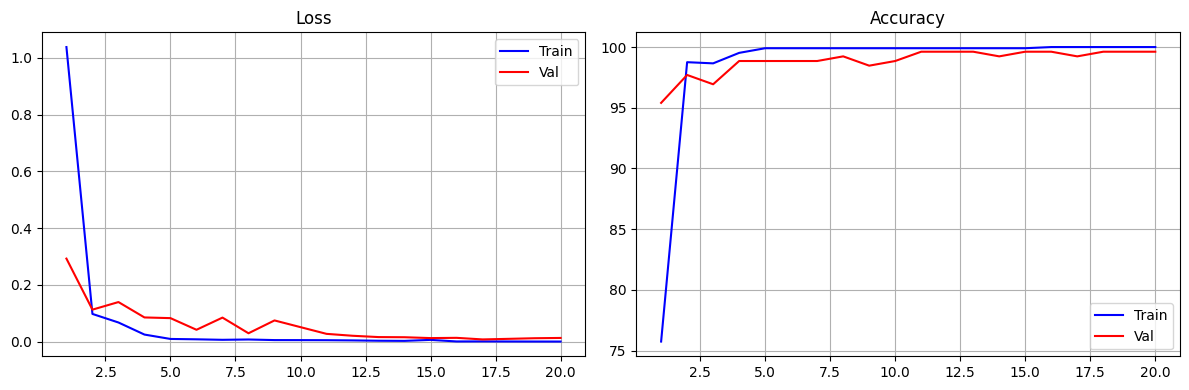


Model saved as video_classifier_clean.pth
Final results: Test 99.69%, Best Val 99.62%


In [17]:
# Evaluation
if training_done:
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for features, masks, labels in test_loader:
            features, masks, labels = features.to(device), masks.to(device), labels.to(device)
            outputs = model(features, masks)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_accuracy = 100 * correct / total
    best_val_acc = max(history['val_acc'])
    
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Best Validation: {best_val_acc:.2f}%")
    
    # Classification report
    report = classification_report(all_labels, all_preds, target_names=label_encoder.classes_, zero_division=0)
    print("\nClassification Report:")
    print(report)
    
    # Plot history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train')
    ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train')
    ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'label_encoder': label_encoder,
        'test_accuracy': test_accuracy,
        'history': history
    }, 'video_classifier_clean.pth')
    
    print("\nModel saved as video_classifier_clean.pth")
    print(f"Final results: Test {test_accuracy:.2f}%, Best Val {best_val_acc:.2f}%")
else:
    print("Training was not completed")